## Лабораторная работа по математической статистике
## "Проверка статистических гипотез"

### I. Проверка параметрических гипотез
В  файле  Mall_Customers.csv содержатся данные опроса покупателей торгового центра 
(источник: https://www.kaggle.com/datasets/shwetabh123/mall-customers). В таблице:
* CustomerID - индивидуальный номер респондента;
* Genre -  пол;
* Age - возраст;
* Annual Income (k$) - годовой доход;
* Spending Score (1-100)  - рейтинг расходов (процент от доходов, который тратятся на 
покупку товаров в торговых центрах)

1. Проверьте утверждение, что « Мужчины и женщины 50% своего дохода тратят в 
супермаркетах» .

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st
from statsmodels.stats.weightstats import ztest
df = pd.read_csv("Mall_Customers.csv")

# 1. H0: средний рейтинг расходов = 50%
#    H1: средний рейтинг расходов != 50%

alpha = 0.05 # 2. уровень значимости (ошибка первого рода)

n = len(df['Spending Score (1-100)']) # 3. объем выборки 
m_star = df['Spending Score (1-100)'].mean() # выборочное среднее
s = np.std(df['Spending Score (1-100)'], ddof=1) # выборочное СКО, несмещенная оценка
m0 = 50 # проверяемое значение

#T распределен по закону Стьюдента с (n-1) степенью свободы
#H1: m != 50 -> двусторонняя критическая область
t_stat = (m_star - m0) * np.sqrt(n) / s

# p-value = 2 * P(T > |t_stat|) для двусторонней области
p_value = 2 * (1 - st.t.cdf(abs(t_stat), df=n-1)) # уровень значимости

print(f"alpha = {alpha}")
print(f"p-value = {p_value:.4f}")

if p_value > alpha:
    print("\nРезультат: p-value > alpha - H0 принимается")
    print("Утверждение подтверждается: средний рейтинг расходов = 50 => Мужчины и женщины в среднем тратят 50% дохода")
else:
    print("Результат: p-value <= alpha - H0 отвергается")
    print("Утверждение не подтверждается: средний рейтинг расходов != 50")
    print(f"Средний показатель: {m_star:.2f}")


alpha = 0.05
p-value = 0.9129

Результат: p-value > alpha - H0 принимается
Утверждение подтверждается: средний рейтинг расходов = 50 => Мужчины и женщины в среднем тратят 50% дохода


2. Проверьте утверждение, что «Доход у мужчин  больше, чем у женщин» с уровнем 
значимости 5%

In [2]:
 #ЗАДАЧА 2 
# H0: Доход мужчин <= Доход женщин
# H1: Доход мужчин > Доход женщин (правосторонняя)
from statsmodels.stats.weightstats import ttest_ind
alpha = 0.05
income_m = df[df['Genre'] == 'Male']['Annual Income (k$)']
income_f = df[df['Genre'] == 'Female']['Annual Income (k$)']
n_m = len(income_m)
n_f = len(income_f)
m_star_m = income_m.mean()
m_star_f = income_f.mean()
s_m = np.std(income_m, ddof=1)
s_f = np.std(income_f, ddof=1)

print(f"Мужчины: n = {n_m}, m* = {m_star_m:.2f}, s = {s_m:.2f}")
print(f"Женщины: n = {n_f}, m* = {m_star_f:.2f}, s = {s_f:.2f}")
# Ручной t-тест (равные дисперсии)
# t = (m1* - m2*) / (s_p * sqrt(1/n1 + 1/n2))
s_p = np.sqrt(((n_m - 1) * s_m**2 + (n_f - 1) * s_f**2) / (n_m + n_f - 2))
t_stat = (m_star_m - m_star_f) / (s_p * np.sqrt(1/n_m + 1/n_f))

# p-value для правосторонней: P(T > t_набл) = 1 - F_t(t_набл, df)
p_value2 = 1 - st.t.cdf(t_stat, df=n_m + n_f - 2)

print(f"\nt-тест, равные дисперсии:")
print(f"  t = {t_stat:.4f}, p-value = {p_value2:.4f}")

if p_value2 > alpha:
    print("\nРезультат: p-value > alpha => H0 принимается")
    print("Утверждение не подтверждается: доход мужчин не больше дохода женщин")
else:
    print("\nРезультат: p-value <= alpha => H0 отвергается, H1 принимается")
    print("Утверждение подтверждается: доход мужчин больше дохода женщин")

Мужчины: n = 88, m* = 62.23, s = 26.64
Женщины: n = 112, m* = 59.25, s = 26.01

t-тест, равные дисперсии:
  t = 0.7950, p-value = 0.2138

Результат: p-value > alpha => H0 принимается
Утверждение не подтверждается: доход мужчин не больше дохода женщин


3. Проверьте гипотезу, что неоднородность возрастов женщин такая же как у мужчин, т. е. что 
дисперсии возраста женщин равна дисперсии возраста мужчин.

In [3]:
# H0: var_age_female = var_age_male
# H1: var_age_female != var_age_male
age_m = df[df['Genre'] == 'Male']['Age']
age_f = df[df['Genre'] == 'Female']['Age']

s2_male = age_m.var(ddof=1)
s2_female = age_f.var(ddof=1)

# критерий фишера
# F = s1^2 / s2^2, где s1^2 - дисперсия
if s2_male >= s2_female:
    F_stat = s2_male / s2_female
    n1 = len(age_m)
    n2 = len(age_f)
    df1 = n1 - 1  # степени свободы для мужчин 
    df2 = n2 - 1  # степени свободы для женщин
else:
    F_stat = s2_female / s2_male
    n1 = len(age_f)
    n2 = len(age_m)
    df1 = n1 - 1   
    df2 = n2 - 1   

# Степени свободы (df) - это количество независимых значений в данных
# Для F-распределения нужно знать df1 и df2, чтобы:
# При маленьких df граница отвержения H0 дальше, при больших df - ближе

# F_крит зависит от df1, df2 и alpha
p_val3 = 2 * (1 - st.f.cdf(F_stat, df1, df2))
F_crit_right = st.f.ppf(1 - alpha/2, df1, df2)
F_crit_left = st.f.ppf(alpha/2, df1, df2)

print(f"Дисперсия возраста мужчин: {s2_male:.2f}")
print(f"Дисперсия возраста женщин: {s2_female:.2f}")
print(f"F-статистика = {F_stat:.2f}")
print(f"Критическая область: a1={F_crit_left:.4f} ; a2 = {F_crit_right:.4f}")
print(f"p-value = {p_val3:.4f}")
print(f"alpha = {alpha}")
print(f"\nГипотеза о равенстве дисперсий возрастов:")
if p_val3 > alpha:
    print("p-value > alpha - H0 принимается. Неоднородность возрастов одинакова")
else:
    print("p-value <= alpha - H0 отвергается. Дисперсии возрастов значимо различаются")

# В пакете statsmodels.stats.weightstats отсутствуют функции для параметрической проверки гипотез о равенстве дисперсий (F-тест). 

Дисперсия возраста мужчин: 240.71
Дисперсия возраста женщин: 159.87
F-статистика = 1.51
Критическая область: a1=0.6676 ; a2 = 1.4834
p-value = 0.0420
alpha = 0.05

Гипотеза о равенстве дисперсий возрастов:
p-value <= alpha - H0 отвергается. Дисперсии возрастов значимо различаются


4. Выяснить, какие  функции для проверки параметрических гипотез есть python-пакете 
statsmodels.stats. В возможных случаях сравнить полученные в пункта 1-3 результаты с 
предсказаниями найденных  функций.
* Проверку проводить с уровнем значимости 5%.
** В пунктах 1-3 проверку гипотезы провести с помощью всех рассмотренных на лекции 
статистических критериев, см. табл. 1 (если для этого понадобятся истинные значения 
математического ожидания и дисперсии, то предположить, что они равны оценочным 
значениям).

In [4]:
# Сравнение ручных расчетов и функций statsmodels
print("\nСРАВНЕНИЕ С STATSMODELS:")
#1.
score = df['Spending Score (1-100)']
z_stat1, p_val11 = ztest(score, value=m0)
print(f"1.  p-value вычисленный вручную: {p_value:.2f}")
print(f"    p-value вычисленный ztest: {p_val11:.2f}")

#2.
t_stat_1, p_value22, df_22 = ttest_ind(income_m, income_f, alternative='larger')
print(f"2.  p-value вычисленный вручную: {p_value2:.2f}")
print(f"    p-value вычисленный ttest: {p_value22:.2f}")

#3. В statsmodels.stats.weightstats нет функции для параметрического F-теста Фишера
print("3.  Дисперсии возраста: в statsmodels.stats функции для F-теста нет.")


СРАВНЕНИЕ С STATSMODELS:
1.  p-value вычисленный вручную: 0.91
    p-value вычисленный ztest: 0.91
2.  p-value вычисленный вручную: 0.21
    p-value вычисленный ttest: 0.21
3.  Дисперсии возраста: в statsmodels.stats функции для F-теста нет.


### II. Проверка непараметрических гипотез
Срок эксплуатации турбореактивного двигателя (характеристика надежности) определяется 
как сумма сроков службы его лопаток.   
    Предполагая, что срок службы ti каждой из N = 100 лопаток описывается экспоненциальным 
законом с параметром интенсивности выхода из строя, равном λ = 2. Все ti  являются 
независимыми.   
   Определите: Какой закон распределения будет иметь надежность всего двигателя? Обоснуйте вывод.
Убедитесь в правильности ответа. 

1) Постройте переменную T (для генерации выборки ti можно использовать произвольное
количество элементов, но желательно больше 100).

In [5]:
import numpy as np

N = 100 # количество лопаток
lam = 2 # интенсивность выхода из строя каждой лопатки
M = 1000 # объем выборки для T 
# Генерация A значений T = t1 + t2 + ... + t{N}
# Каждое ti = Exp(lambda)
ti=np.random.exponential(scale=1/lam, size=(M, N))
T = ti.sum(axis=1)
print(f"Сгенерировано {M} значений T")
print(len(ti))
print(f"Первые 10 значений T: {T[:10]}")

Сгенерировано 1000 значений T
1000
Первые 10 значений T: [49.12209111 58.8908252  49.47957674 49.28718181 54.69722157 48.61659979
 53.81259368 61.38943172 52.08642321 43.75378644]


2) Вычислите параметры предполагаемого закона распределения T и сравните их с 
теоретическими.

In [6]:
# (слайд 19) H0 : g(x;theta) = f(x;theta)
# По ЦПТ при N=100 T имеет приближенно нормальное распределение

# Теоретические параметры (нормальный закон)
# f(t) = lambda * exp^(-lambda * t),  t >= 0
# Для экспоненциального распределения M[t_i] = интеграл от 0 до бесконечности t * f(t) dt = 1 / lambda, D[t_i = M[t_i^2] - (M[t_i])^2 = 1 / lambda^2
theor_mean = N / lam 
# M[T] = N * M[t_i] = N * (1/lambda) = 100 * 0.5 = 50 тк все t_i имеют одинаковое распределение
theor_sigma = np.sqrt(N) / lam 
# sigma(T) = sqrt(D[T]) = sqrt(N * D[t_i]) = sqrt(N) * sigma(t_i) = 10 * 0.5 = 5 тк все t_i независимы и одинаково распределены

# Эмпирические параметры
emp_mean = np.mean(T)
emp_sigma = np.std(T, ddof=1) # несмещенная оценка (деление на n-1)

print("Предполагаемый закон: нормальный (по ЦПТ)")
print(f"Теоретические параметры: mu = {theor_mean}, sigma = {theor_sigma}")
print(f"Эмпирические параметры: mu_emp = {emp_mean:.4f}, sigma_emp = {emp_sigma:.4f}")
print(f"Отклонение по mu: {abs(emp_mean - theor_mean):.4f}")
print(f"Отклонение по sigma: {abs(emp_sigma - theor_sigma):.4f}")

Предполагаемый закон: нормальный (по ЦПТ)
Теоретические параметры: mu = 50.0, sigma = 5.0
Эмпирические параметры: mu_emp = 50.1523, sigma_emp = 4.7467
Отклонение по mu: 0.1523
Отклонение по sigma: 0.2533


3) Постройте гистограммы относительных частот и эмпирическую функцию распределения
для T.

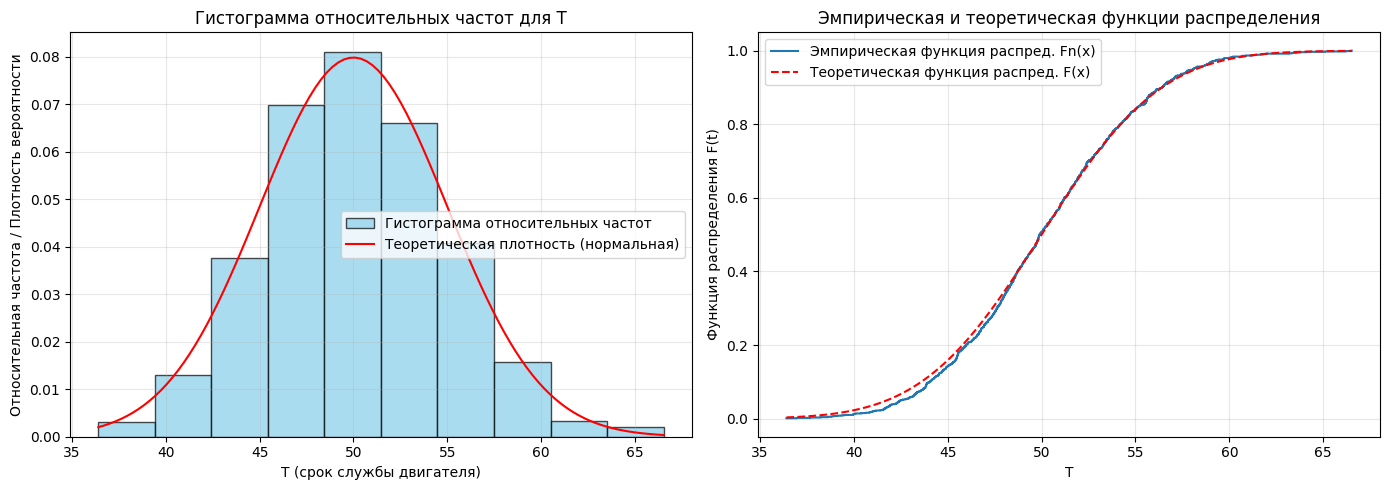

In [7]:
import matplotlib.pyplot as plt
from scipy.stats import norm

x_teor = np.linspace(min(T), max(T), 100)
f_x = norm.pdf(x_teor, theor_mean, theor_sigma) # теоретическая плотность
F_x = norm.cdf(x_teor, theor_mean, theor_sigma) # теоретическая функция распределения

plt.figure(figsize=(14, 5))

# Гистограмма относительных частот
# (слайд 21) Относительная частота n_j/n попадания данных
plt.subplot(1, 2, 1)
plt.hist(T, bins=10, density=True, alpha=0.7, color='skyblue', 
         edgecolor='black', label='Гистограмма относительных частот')
# Теоретическая нормальная плотность
plt.plot(x_teor, f_x, 'r-', label='Теоретическая плотность (нормальная)')
plt.xlabel('T (срок службы двигателя)')
plt.ylabel('Относительная частота / Плотность вероятности')
plt.title('Гистограмма относительных частот для T')
plt.legend()
plt.grid(True, alpha=0.3)

# Эмпирическая функция распределения
# F_n(x) = 0 при x < x_1, F_n(x) = i/n при x_i <= x < x_{i+1}, F_n(x) = 1 при x >= x_n
plt.subplot(1, 2, 2)
x_sorted  = np.sort(T)
ecdf = np.arange(1, M + 1) / M   # i/n
plt.step(x_sorted , ecdf, where='post', label='Эмпирическая функция распред. Fn(x)', lw=1.5)
# Теоретическая функция распределения
plt.plot(x_teor, F_x, 'r--',label='Теоретическая функция распред. F(x)')

plt.xlabel('T')
plt.ylabel('Функция распределения F(t)')
plt.title('Эмпирическая и теоретическая функции распределения')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print()

4) Проверьте гипотезу о предполагаемом виде закона распределения.

In [8]:
import scipy.stats as st
ti = np.random.exponential(scale=1/lam, size=(1000, N))
T = ti.sum(axis=1)
shape = N
loc = 0
scale = 1/lam
stat, p = st.kstest(T, 'gamma', args=(shape, loc, scale))
print(f"колмогоров-смирнов D={stat:.4f}, p={p:.4f}")
if p < 0.05:
    print("Результат: p < alpha - H0 отвергается")
    print("Распределение T отличается гамм")
else:
    print("Результат: p >= alpha - H0 принимается")
    print("Распределение T не отличается гамме")
print()


x_sorted = np.sort(T)
ecdf = np.arange(1, M + 1) / M
D_n_gamma = np.max(np.abs(ecdf - st.gamma.cdf(x_sorted, shape, loc, scale)))
Z_gamma = np.sqrt(M) * D_n_gamma
lambda_alpha = 1.358

print(f"D_n = max |F_n(x) - F(x)| = {D_n_gamma:.4f}")
print(f"Z = sqrt(n) * D_n = sqrt({M}) * {D_n_gamma:.4f} = {Z_gamma:.4f}")
print(f"Критическое значение lambda_alpha (alpha=0.05) = {lambda_alpha}")
if Z_gamma < lambda_alpha:
    print("Результат: Z < lambda_alpha - H0 принимается")
    print("Распределение T не противоречит гамме")
else:
    print("Результат: Z >= lambda_alpha - H0 отвергается")
    print("Распределение T отличается от гамма")
print()

колмогоров-смирнов D=0.0192, p=0.8456
Результат: p >= alpha - H0 принимается
Распределение T не отличается гамме

D_n = max |F_n(x) - F(x)| = 0.0182
Z = sqrt(n) * D_n = sqrt(1000) * 0.0182 = 0.5769
Критическое значение lambda_alpha (alpha=0.05) = 1.358
Результат: Z < lambda_alpha - H0 принимается
Распределение T не противоречит гамме



In [9]:
import scipy.stats as st
ti = np.random.exponential(scale=1/lam, size=(1000, N))
T = ti.sum(axis=1)
M=1000
theor_mean = N / lam
theor_sigma = np.sqrt(N) / lam 
stat, p = st.kstest(T, 'norm', args=(theor_mean, theor_sigma))
print(f"колмогоров-смирнов ={stat:.4f}, p={p:.4f}")
if p < 0.05:
    print("Результат: p < alpha - H0 отвергается")
    print("Распределение T отличается норм")
else:
    print("Результат: p >= alpha - H0 принимается")
    print("Распределение T не отличается норм")
print()
x_sorted = np.sort(T)
ecdf = np.arange(1, M + 1) / M
theor_mean = N / lam
theor_sigma = np.sqrt(N) / lam 
D_n = np.max(np.abs(ecdf - st.norm.cdf(x_sorted, theor_mean, theor_sigma)))
Z = np.sqrt(M) * D_n
lambda_alpha = 1.358

print(f"D_n = max |F_n(x) - F(x)| = {D_n:.4f}")
print(f"Z = sqrt(n) * D_n = sqrt({M}) * {D_n:.4f} = {Z:.4f}")
print(f"Критическое значение lambda_alpha (alpha=0.05) = {lambda_alpha}")
if Z < lambda_alpha:
    print("Результат: Z < lambda_alpha - H0 принимается")
    print("Распределение T не противоречит норм")
else:
    print("Результат: Z >= lambda_alpha - H0 отвергается")
    print("Распределение T отличается от норм")
print()

колмогоров-смирнов =0.0234, p=0.6341
Результат: p >= alpha - H0 принимается
Распределение T не отличается норм

D_n = max |F_n(x) - F(x)| = 0.0234
Z = sqrt(n) * D_n = sqrt(1000) * 0.0234 = 0.7407
Критическое значение lambda_alpha (alpha=0.05) = 1.358
Результат: Z < lambda_alpha - H0 принимается
Распределение T не противоречит норм



In [10]:
import scipy.stats as st
ti = np.random.exponential(scale=1/lam, size=(1000, N))
T = ti.sum(axis=1)
shape = N
loc = 0
scale = 1/lam
stat, p = st.kstest(T, 'gamma', args=(shape, loc, scale))
print(f"колмогоров-смирнов ={stat:.4f}, p={p:.4f}")
if p < 0.05:
    print("Результат: p < alpha - H0 отвергается")
    print("Распределение T отличается гамм")
else:
    print("Результат: p >= alpha - H0 принимается")
    print("Распределение T не отличается гамме")
print()
x_sorted = np.sort(T)
ecdf = np.arange(1, M + 1) / M
D_n_gamma = np.max(np.abs(ecdf - st.gamma.cdf(x_sorted, shape, loc, scale)))
Z_gamma = np.sqrt(M) * D_n_gamma
lambda_alpha = 1.358

print(f"D_n = max |F_n(x) - F(x)| = {D_n_gamma:.4f}")
print(f"Z = sqrt(n) * D_n = sqrt({M}) * {D_n_gamma:.4f} = {Z_gamma:.4f}")
print(f"Критическое значение lambda_alpha (alpha=0.05) = {lambda_alpha}")
if Z_gamma < lambda_alpha:
    print("Результат: Z < lambda_alpha - H0 принимается")
    print("Распределение T не противоречит гамме")
else:
    print("Результат: Z >= lambda_alpha - H0 отвергается")
    print("Распределение T отличается от гамма")
print()

колмогоров-смирнов =0.0212, p=0.7532
Результат: p >= alpha - H0 принимается
Распределение T не отличается гамме

D_n = max |F_n(x) - F(x)| = 0.0212
Z = sqrt(n) * D_n = sqrt(1000) * 0.0212 = 0.6693
Критическое значение lambda_alpha (alpha=0.05) = 1.358
Результат: Z < lambda_alpha - H0 принимается
Распределение T не противоречит гамме



In [11]:
# (слайд 19) Проверка гипотез о виде закона распределения
# H0 : g(x;theta) = f(x;theta) (истинный = гипотетическому)
# H1 : нулевая гипотеза не верна

# H0: T распределена по нормальному закону с параметрами mu = theor_mean, sigma = theor_sigma
# H1: T не распределена по нормальному закону

# (слайд 24) Критерий Колмогорова
# D_n = max |F_n(x) - F(x)| -максимальная разность
# Z = sqrt(n) * D_n
# Слайд 25: H0 принимается, если Z < lambda_alpha
# Таблица lambda_alpha на слайде 24
x_sorted = np.sort(T)
ecdf = np.arange(1, M + 1) / M
theor_mean = N / lam
theor_sigma = np.sqrt(N) / lam 
D_n = np.max(np.abs(ecdf - st.norm.cdf(x_sorted, theor_mean, theor_sigma)))
Z = np.sqrt(M) * D_n
lambda_alpha = 1.358
# Таблица lambda_alpha (слайд 24), alpha = 0.05 -> lambda_alpha = 1.358

print(f"D_n = max |F_n(x) - F(x)| = {D_n:.6f}")
print(f"Z = sqrt(n) * D_n = sqrt({M}) * {D_n:.6f} = {Z:.4f}")
print(f"Критическое значение lambda_alpha (alpha=0.05) = {lambda_alpha}")
print()

if Z < lambda_alpha:
    print("Результат: Z < lambda_alpha - H0 принимается")
    print("Распределение T не противоречит нормальному закону")
else:
    print("Результат: Z >= lambda_alpha - H0 отвергается")
    print("Распределение T отличается от нормального")
print()

# (слайд 20) Критерий Хи-квадрат Пирсона
# хи-квадрат = сумма (n_j - n*p_j)^2 / (n*p_j)
# n_j - частота попадания в j-й интервал
# p_j = F(x_{j+1}) - F(x_j) - вероятность попадания в j-й интервал
# (слайд 21) H0 принимается, если хи-квадрат < хи-квадрат_кр
# (слайд 21) Диапазон изменения данных разбивается на m интервалов
m = int(1 + np.log2(M))
print(f"Количество интервалов: {m}")

# n_j — это частоты, krai — это границы интервалов
n_j, krai = np.histogram(T, bins=m)
p_theor = st.norm.cdf(krai[1:], theor_mean, theor_sigma) - st.norm.cdf(krai[:-1], theor_mean, theor_sigma)
np_j = M * p_theor

# (слайд 21) статистику хи-квадрат можно использовать, когда n*p_j > 5
a = np_j >= 5
n_j = n_j[a]
np_j = np_j[a]
print(f"Используется интервалов: {len(n_j)} (только с np_j >= 5)")

chi2_stat = np.sum((n_j - np_j) ** 2 / np_j) # Считаем хи-квадрат по формуле
# (слайд 22) число степеней свободы = m - k - 1, k=2 (mu и sigma)
df = len(np_j) - 1 - 2
alpha = 0.05
crit_znach = st.chi2.ppf(1 - alpha, df)

print(f"Статистика хи-квадрат = {chi2_stat:.4f}")
print(f"Число степеней свободы df = {df}")
print(f"Критическое значение (alpha={alpha}) = {crit_znach:.4f}")

if chi2_stat < crit_znach:
    print("Результат: chi2 < chi2_кр - H0 принимается")
    print("Данные соответствуют нормальному распределению")
else:
    print("Результат: chi2 > chi2_кр - H0 отвергается")
    print("Данные не соответствуют нормальному распределению")
    
print("\nПоскольку оба критерия не отвергают H0 на уровне alpha=0.05, то распределение T можно считать нормальным с параметрами:")
print(f"mu = {theor_mean}; sigma = {theor_sigma}")
print("Это соответствует ЦПТ: сумма 100 независимых экспоненциальных случайных величин имеет приближенно нормальное распределение.")

D_n = max |F_n(x) - F(x)| = 0.020127
Z = sqrt(n) * D_n = sqrt(1000) * 0.020127 = 0.6365
Критическое значение lambda_alpha (alpha=0.05) = 1.358

Результат: Z < lambda_alpha - H0 принимается
Распределение T не противоречит нормальному закону

Количество интервалов: 10
Используется интервалов: 9 (только с np_j >= 5)
Статистика хи-квадрат = 12.9311
Число степеней свободы df = 6
Критическое значение (alpha=0.05) = 12.5916
Результат: chi2 > chi2_кр - H0 отвергается
Данные не соответствуют нормальному распределению

Поскольку оба критерия не отвергают H0 на уровне alpha=0.05, то распределение T можно считать нормальным с параметрами:
mu = 50.0; sigma = 5.0
Это соответствует ЦПТ: сумма 100 независимых экспоненциальных случайных величин имеет приближенно нормальное распределение.
